Filled missing values in 'ca' with mode: 0.0
Filled missing values in 'thal' with mode: 3.0
Dataset loaded successfully from UCI URL.
Primeras filas:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  ----- 

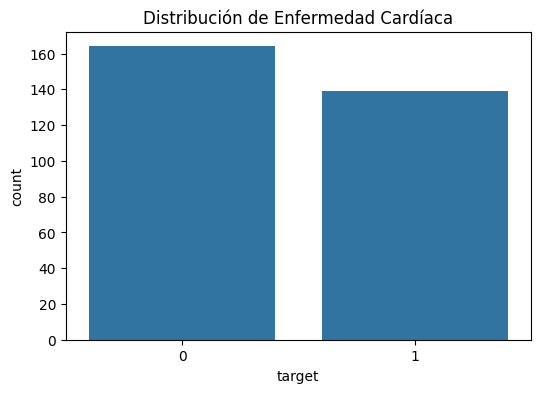

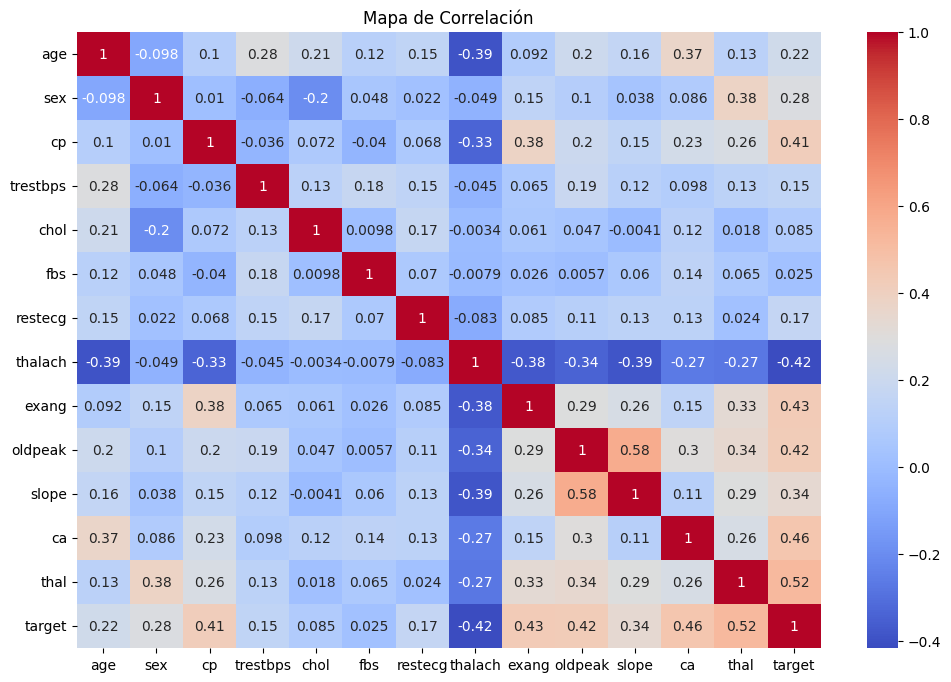

Datos de entrenamiento: (242, 13)
Datos de prueba: (61, 13)
Predicciones: [0 1 1 0 1 1 1 1 0 1]
Accuracy: 0.7213114754098361

Matriz de confusión:
[[22  7]
 [10 22]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        29
           1       0.76      0.69      0.72        32

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



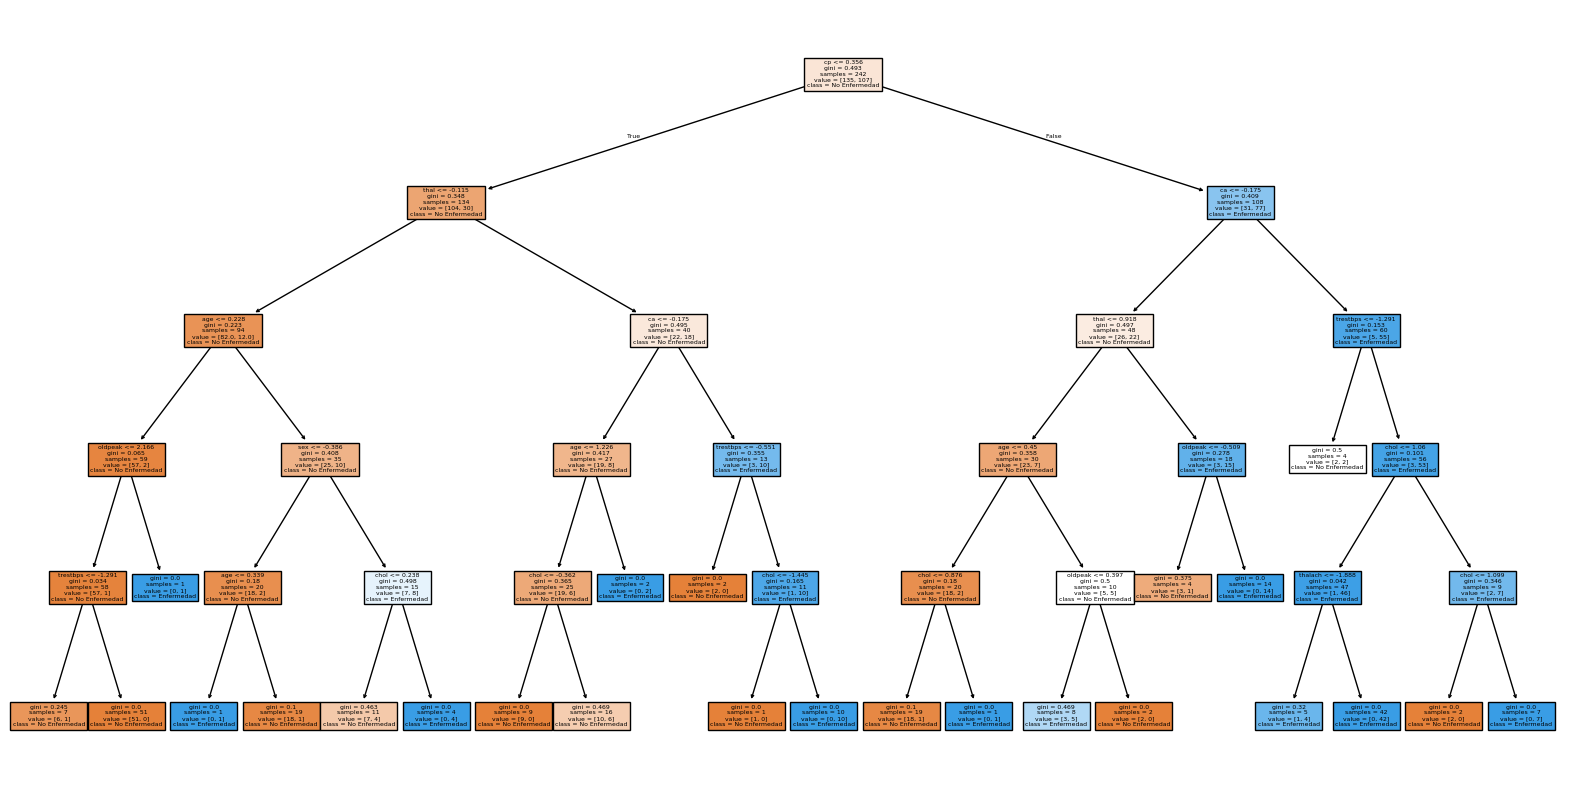

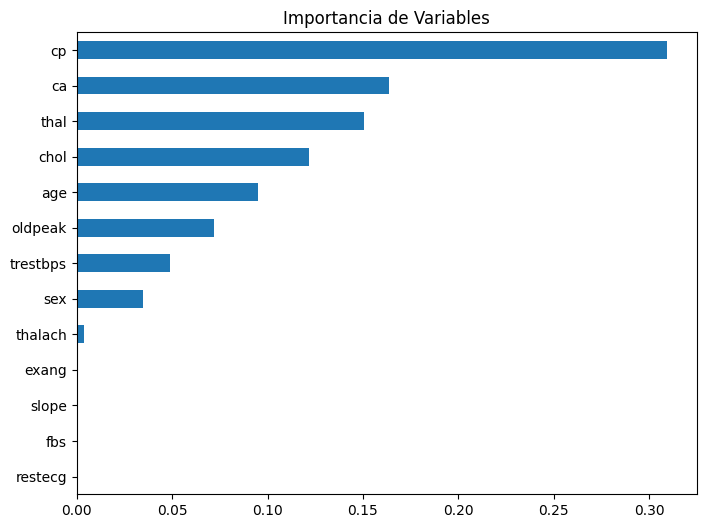

restecg     0.000000
fbs         0.000000
slope       0.000000
exang       0.000000
thalach     0.003867
sex         0.034825
trestbps    0.049078
oldpeak     0.071930
age         0.094811
chol        0.121602
thal        0.150710
ca          0.163672
cp          0.309506
dtype: float64
Modelo guardado correctamente
Predicción: No Enfermedad


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import io

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import joblib

# =========================
# DATASET
# =========================
# Changed to use the 'processed' version which is typically cleaner
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = None

try:
    response = requests.get(uci_url)
    response.raise_for_status()

    if not response.text.strip():
        raise ValueError(f"Downloaded content from {uci_url} is empty.")

    temp_df = pd.read_csv(
        io.StringIO(response.text),
        sep=',', # Changed separator to comma for processed.cleveland.data
        names=column_names,
        na_values='?',
        engine='python'
    )

    for col in ['ca', 'thal']:
        if temp_df[col].isnull().any():
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
            mode_val = temp_df[col].mode()[0]
            temp_df[col] = temp_df[col].fillna(mode_val) # Modified: Removed inplace=True
            print(f"Filled missing values in '{col}' with mode: {mode_val}")

    df = temp_df.dropna()

    if df.empty:
        raise ValueError("DataFrame is empty after handling missing values.")

    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

    print("Dataset loaded successfully from UCI URL.")

except (requests.exceptions.RequestException, ValueError, pd.errors.EmptyDataError) as e:
    print(f"Error loading dataset from UCI URL: {e}")
    print("Attempting to use fallback dataset.")

    # Updated fallback_url to a working GitHub raw CSV
    fallback_url = "https://raw.githubusercontent.com/Anirudh070/Heart-Disease-UCI/main/heart.csv"

    try:
        response = requests.get(fallback_url)
        response.raise_for_status()

        if not response.text.strip():
            raise ValueError(f"Downloaded content from {fallback_url} is empty.")

        df = pd.read_csv(io.StringIO(response.text))
        # The fallback dataset might have different column names, adjust if necessary
        # For 'heart.csv' from UCI, 'target' is already 0 or 1, and columns are standard.
        if 'target' not in df.columns:
            raise ValueError("Fallback dataset does not contain 'target' column.")
        print("Fallback dataset loaded successfully.")

    except (requests.exceptions.RequestException, ValueError, pd.errors.EmptyDataError) as e_fallback:
        print(f"Error loading fallback dataset: {e_fallback}")
        raise SystemExit("Could not retrieve any dataset.")

if df is None or df.empty:
    raise SystemExit("No dataset could be loaded or dataset is empty.")

print("Primeras filas:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

# =========================
# ANÁLISIS EXPLORATORIO
# =========================
print("\nEstadísticas:")
print(df.describe())

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Distribución de Enfermedad Cardíaca")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Correlación")
plt.show()

# =========================
# VARIABLES
# =========================
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN / TEST
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

# =========================
# MODELO ÁRBOL DE DECISIÓN
# =========================
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

modelo.fit(X_train, y_train)

# =========================
# PREDICCIONES
# =========================
y_pred = modelo.predict(X_test)

print("Predicciones:", y_pred[:10])

# =========================
# MÉTRICAS
# =========================
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# =========================
# VISUALIZACIÓN DEL ÁRBOL
# =========================
plt.figure(figsize=(20,10))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['No Enfermedad', 'Enfermedad'],
    filled=True
)
plt.show()

# =========================
# IMPORTANCIA
# =========================
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values()

plt.figure(figsize=(8,6))
importancias.plot(kind='barh')
plt.title("Importancia de Variables")
plt.show()

print(importancias)

# =========================
# GUARDAR MODELO
# =========================
joblib.dump(modelo, 'modelo_arbol_cardiaco.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Modelo guardado correctamente")

# =========================
# CARGAR MODELO
# =========================
modelo_cargado = joblib.load('modelo_arbol_cardiaco.pkl')
scaler_cargado = joblib.load('scaler.pkl')

nuevo_paciente = np.array([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

nuevo_paciente = scaler_cargado.transform(nuevo_paciente)

prediccion = modelo_cargado.predict(nuevo_paciente)

print("Predicción:", "Enfermedad" if prediccion[0] == 1 else "No Enfermedad")